In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../src') 

from utils.constants import PROJECT_CRS
from tables_setup import *
from utils.paths import *
from utils.data_processing import *
from utils.sedona_config import get_spark

import time
import logging
import pandas as pd
import geopandas as gpd
import pydeck as pdk
from sedona.maps.SedonaKepler import SedonaKepler
from sedona.maps.SedonaPyDeck import SedonaPyDeck

In [2]:
sedona = get_spark()
tables = load_tables(sedona)

25/05/07 06:49:20 WARN Utils: Your hostname, kinabalu resolves to a loopback address: 127.0.1.1; using 128.232.93.1 instead (on interface eno12399np0)
25/05/07 06:49:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://artifacts.unidata.ucar.edu/repository/unidata-all added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/acz25/.ivy2/cache
The jars for the packages stored in: /home/acz25/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
net.postgis#postgis-jdbc added as a dependency
net.postgis#postgis-geometry added as a dependency
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-fb93f72d-58d2-45d1-94ea-9f18a9397986;1.0
	confs: [default]
	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.0 in user-list


:: loading settings :: url = jar:file:/maps-priv/maps/acz25/envs/3-30-300-env/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.apache.sedona#sedona-common;1.7.0 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in user-list
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-annotations;1.1 in central
	found org.codehaus.mojo#animal-sniffer-annotations;1.14 in central
	found com.uber#h3;4.1.1 in central
	found net.sf.geographiclib#GeographicLib-Java;1.52 in central
	found com.github.ben-manes.caffeine#caffeine;2.9.2 in central
	found org.checkerframework#checker-qual;3.10.0 in central
	found com.google.errorprone#error_prone_annotations;2.5.1 in central
	found org.apac

In [3]:
output_areas_boundaries_gdf = tables['output_areas_boundaries_gdf'] 
os_tile_boundaries_gdf = tables['os_tile_boundaries_gdf'] 
output_areas_os_tile_overlay_df = tables['output_areas_os_tile_overlay_df']
output_areas_buildings_overlay_sdf = tables['output_areas_buildings_overlay_sdf']
vom_raster_paths_df = tables['vom_raster_paths_df'] 
tree_vector_paths_df = tables['tree_vector_paths_df']
road_nodes_gdf = tables['road_nodes_gdf'] 
road_edges_gdf = tables['road_edges_gdf']
green_space_site_gdf = tables['green_space_site_gdf']
green_space_access_gdf = tables['green_space_access_gdf']
buildings_sdf = tables['buildings_sdf']

In [4]:
output_areas_boundaries_sdf = sedona.createDataFrame(output_areas_boundaries_gdf)
output_areas_boundaries_sdf.createOrReplaceTempView('boundaries')
buildings_sdf.createOrReplaceTempView("buildings")
output_areas_buildings_overlay_sdf.createOrReplaceTempView('output_areas_buildings_overlay')
public_park_site_gdf = green_space_site_gdf.copy()[green_space_site_gdf['function'] == 'Public Park Or Garden'].reset_index(drop=True)
public_park_site_sdf = sedona.createDataFrame(public_park_site_gdf)
public_park_site_sdf.createOrReplaceTempView('public_park_sites')
public_park_access_gdf = green_space_access_gdf.copy()[green_space_access_gdf['ref_to_greenspace_site'].isin(public_park_site_gdf.id)].reset_index(drop=True)
public_park_access_sdf = sedona.createDataFrame(public_park_access_gdf)
public_park_access_sdf.createOrReplaceTempView('public_park_accesses')

In [5]:
t3_300_sdf = sedona.read.format("parquet").load(str(database_dir / 't3_300.parquet'))
t3_300_sdf.createOrReplaceTempView('t3_300')

In [6]:
query_method = 'rdd'
tile_level = 'TILE_NAME_50KM'
geo_code = 'E07000008'  # Cambridge
geo_level = 'LAD22CD'
buffer = 100

In [10]:
t3_300_sdf.printSchema()

root
 |-- verisk_premise_id: long (nullable = true)
 |-- closest_park_access_id: string (nullable = true)
 |-- distance_manhattan: double (nullable = true)
 |-- closest_park_site_id: string (nullable = true)
 |-- distance_euclidean: double (nullable = true)
 |-- tree_count_10m: double (nullable = true)
 |-- tree_count_25m: double (nullable = true)
 |-- tree_count_50m: double (nullable = true)
 |-- tree_count_75m: double (nullable = true)
 |-- tree_count_100m: double (nullable = true)
 |-- tree_count_slope: double (nullable = true)
 |-- park_distance_ratio: double (nullable = true)
 |-- park_distance_diff: double (nullable = true)



In [13]:
geo_buildings_sdf = sedona.sql(f"""
SELECT b.map_use, b.height, b.distance_water, t3.tree_count_10m, t3.tree_count_25m, t3.tree_count_slope,
t3.tree_count_50m, t3.tree_count_75m, t3.tree_count_100m, t3.distance_manhattan, t3.distance_euclidean, 
t3.park_distance_ratio, t3.park_distance_diff, 
ST_TRANSFORM(b.geometry, '{PROJECT_CRS}', 'EPSG:4326') as geometry FROM buildings b
JOIN output_areas_buildings_overlay oab ON b.verisk_premise_id = oab.verisk_premise_id
LEFT JOIN t3_300 t3 ON b.verisk_premise_id = t3.verisk_premise_id
WHERE oab.{geo_level} = '{geo_code}' AND b.map_use = 'Residential'
AND t3.distance_manhattan IS NOT NULL
""")

In [9]:
geo_buildings_sdf.printSchema()

root
 |-- map_use: string (nullable = true)
 |-- height: double (nullable = true)
 |-- distance_water: double (nullable = true)
 |-- tree_count_25m: double (nullable = true)
 |-- distance_manhattan: double (nullable = true)
 |-- distance_euclidean: double (nullable = true)
 |-- geometry: geometry (nullable = true)



In [14]:
geo_buildings_sdf.coalesce(1) \
    .write.format("geoparquet").save(str(database_dir / 'clipped_data_buildings'))

In [15]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
from matplotlib import cm
from matplotlib.colors import Normalize
# Initialize the colormap and normalization
cmap = cm.get_cmap('PiYG_r')
norm = Normalize(vmin=geo_buildings_sdf.select("log_distance_manhattan").rdd.flatMap(lambda x: x).min(),
                 vmax=geo_buildings_sdf.select("log_distance_manhattan").rdd.flatMap(lambda x: x).max())

# Define a UDF to calculate the color
def calculate_color(value):
    normalized_value = norm(value)
    rgba_color = cmap(normalized_value)
    return f"[{int(rgba_color[0] * 255)}, {int(rgba_color[1] * 255)}, {int(rgba_color[2] * 255)}]"

color_udf = udf(calculate_color, StringType())

# Add the color column to the DataFrame
geo_buildings_sdf = geo_buildings_sdf.withColumn(
    "color", color_udf(geo_buildings_sdf["log_distance_manhattan"])
)

/tmp/ipykernel_1513422/1418024526.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('PiYG_r')


AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `log_distance_manhattan` cannot be resolved. Did you mean one of the following? [`t3`.`distance_manhattan`, `b`.`distance_water`, `t3`.`distance_euclidean`, `t3`.`park_distance_ratio`, `geometry`].;
'Project ['log_distance_manhattan]
+- Project [map_use#36, height#34, distance_water#33, tree_count_10m#142, tree_count_25m#143, tree_count_slope#147, tree_count_50m#144, tree_count_75m#145, tree_count_100m#146, distance_manhattan#139, distance_euclidean#141, park_distance_ratio#148, park_distance_diff#149,  **org.apache.spark.sql.sedona_sql.expressions.ST_Transform**   AS geometry#1178]
   +- Filter (((LAD22CD#23 = E07000008) AND (map_use#36 = Residential)) AND isnotnull(distance_manhattan#139))
      +- Join LeftOuter, (verisk_premise_id#42L = verisk_premise_id#137L)
         :- Join Inner, (verisk_premise_id#42L = verisk_premise_id#19L)
         :  :- SubqueryAlias b
         :  :  +- Subquery

In [13]:
geo_buildings_df = geo_buildings_sdf.toPandas()
geo_buildings_gdf = gpd.GeoDataFrame(geo_buildings_df, geometry='geometry', crs='EPSG:4326')

/tmp/ipykernel_126701/2996153227.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('PiYG_r')


<Figure size 2000x2000 with 0 Axes>

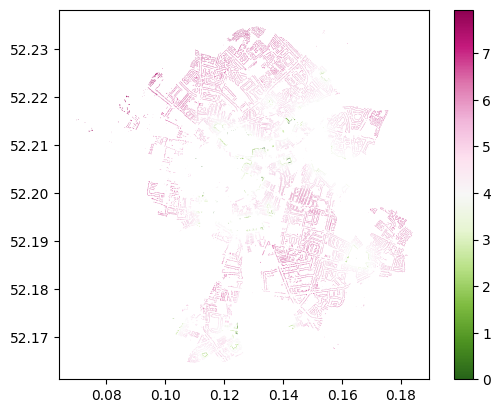

In [14]:
from matplotlib import cm
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 20))
geo_buildings_gdf.plot(column='log_distance_euclidean', legend=True, cmap='PiYG_r')

# Normalize the data to the range of the colormap
norm = Normalize(vmin=geo_buildings_gdf['log_distance_euclidean'].min(), vmax=geo_buildings_gdf['log_distance_euclidean'].max())
cmap = cm.get_cmap('PiYG_r')

# Map the normalized values to colors
# geo_buildings_gdf['color'] = geo_buildings_gdf['log_distance_euclidean'].apply(lambda x: cmap(norm(x)))

In [16]:
# Load a map with data and config and height
from keplergl import KeplerGl
map_2 = KeplerGl(height=400, data={"data_1": geo_buildings_gdf[['geometry']]})
map_2

NameError: name 'geo_buildings_gdf' is not defined

In [ ]:
INITIAL_VIEW_STATE = pdk.ViewState(latitude=52.20451158061835, longitude=0.12823234624236227, zoom=11, max_zoom=17, pitch=45, bearing=0)
SedonaPyDeck.create_choropleth_map(geo_buildings_sdf, plot_col='distance_euclidean', elevation_col='height',
                                   map_style=pdk.map_styles.LIGHT, initial_view_state=INITIAL_VIEW_STATE)